In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [28]:
import pickle
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

In [29]:
air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")

In [30]:
# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. Data Pipeline & Scaling
# ==========================================
df = dataset[["pm2_5 (μg/m³)", "timestamp"]].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("H")
df["pm2_5 (μg/m³)"] = df["pm2_5 (μg/m³)"].interpolate(method="linear")

# Scale features between 0 and 1 (Critical for Neural Network stability)
scaler = MinMaxScaler()
df["scaled_pm25"] = scaler.fit_transform(df[["pm2_5 (μg/m³)"]])

# Define input/output window horizons
input_window = 24  # Look back 24 hours
output_window = 24  # Predict next 24 hours directly


# Vectorized window generation function
def create_sequences(data, input_w, output_w):
    X, Y = [], []
    for i in range(len(data) - input_w - output_w + 1):
        X.append(data[i : i + input_w])
        Y.append(data[i + input_w : i + input_w + output_w])
    return np.array(X), np.array(Y)


# Chronological splits
train_series = df.loc[:"2024-12-31 23:00:00", "scaled_pm25"].values
test_series = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00", "scaled_pm25"].values

X_train, y_train = create_sequences(train_series, input_window, output_window)
X_test, y_test = create_sequences(test_series, input_window, output_window)

# Convert to PyTorch Tensors and create DataLoader
train_dataset = TensorDataset(
    torch.FloatTensor(X_train).unsqueeze(-1), torch.FloatTensor(y_train)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


/tmp/ipykernel_303227/2358299807.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.sort_index().asfreq("H")


In [31]:
# ==========================================
# 2. Network Architecture
# ==========================================
class PM25LSTM(nn.Module):

    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=24):
        super(PM25LSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_hidden = lstm_out[:, -1, :]
        out = self.fc(last_hidden)
        return out


model = PM25LSTM(output_dim=output_window).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [32]:
# ==========================================
# 3. Model Training Loop
# ==========================================
model.train()
epochs = 20  # Increase epochs for production accuracy

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss/len(train_loader):.5f}")

Epoch 1/20 - Loss: 0.00387
Epoch 2/20 - Loss: 0.00319
Epoch 3/20 - Loss: 0.00311
Epoch 4/20 - Loss: 0.00309
Epoch 5/20 - Loss: 0.00306
Epoch 6/20 - Loss: 0.00305
Epoch 7/20 - Loss: 0.00304
Epoch 8/20 - Loss: 0.00302
Epoch 9/20 - Loss: 0.00301
Epoch 10/20 - Loss: 0.00301
Epoch 11/20 - Loss: 0.00300
Epoch 12/20 - Loss: 0.00299
Epoch 13/20 - Loss: 0.00299
Epoch 14/20 - Loss: 0.00298
Epoch 15/20 - Loss: 0.00297
Epoch 16/20 - Loss: 0.00297
Epoch 17/20 - Loss: 0.00297
Epoch 18/20 - Loss: 0.00296
Epoch 19/20 - Loss: 0.00296
Epoch 20/20 - Loss: 0.00296


In [33]:
# ==========================================
# 4. Multi-Step Forecast Generation
# ==========================================
model.eval()
with torch.no_grad():
    # Isolate the exact 24 hours prior to January 1st, 2025 as seed input
    seed_input = (
        torch.FloatTensor(train_series[-input_window:])
        .view(1, input_window, 1)
        .to(device)
    )
    scaled_prediction = model(seed_input).cpu().numpy().flatten()

# Inverse transform back to true units (μg/m³)
true_predictions = scaler.inverse_transform(scaled_prediction.reshape(-1, 1)).flatten()
actual_values = scaler.inverse_transform(y_test[0].reshape(-1, 1)).flatten()

# Timestamps for plotting the forecast horizon
forecast_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-01 23:00:00"].index


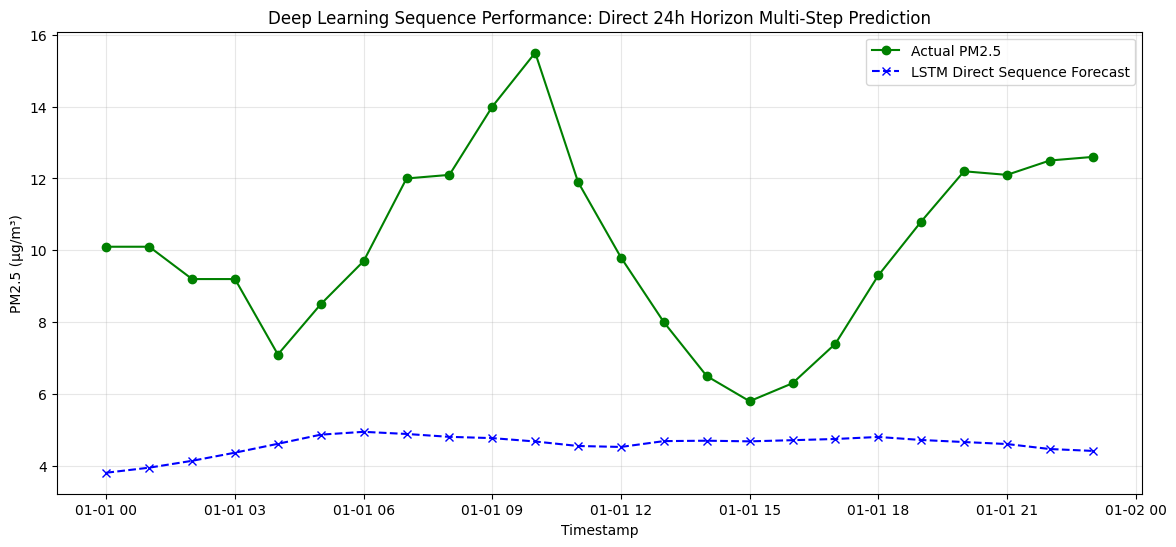

In [34]:
# ==========================================
# 5. Visual Validation
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(
    forecast_timestamps,
    actual_values,
    label="Actual PM2.5",
    color="green",
    marker="o",
)
plt.plot(
    forecast_timestamps,
    true_predictions,
    label="LSTM Direct Sequence Forecast",
    color="blue",
    linestyle="--",
    marker="x",
)
plt.title(
    "Deep Learning Sequence Performance: Direct 24h Horizon Multi-Step Prediction"
)
plt.ylabel("PM2.5 (μg/m³)")
plt.xlabel("Timestamp")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()